# Spline

S_0(x) = 0.0000x^2 + 1.0000x + 1.0000, for 0 <= x <= 1
S_1(x) = 30.0000x^2 + -59.0000x + 31.0000, for 1 <= x <= 2
S_2(x) = 150.0000x^2 + -539.0000x + 511.0000, for 2 <= x <= 3
Interpolated value at x = 1.5: 10.0000


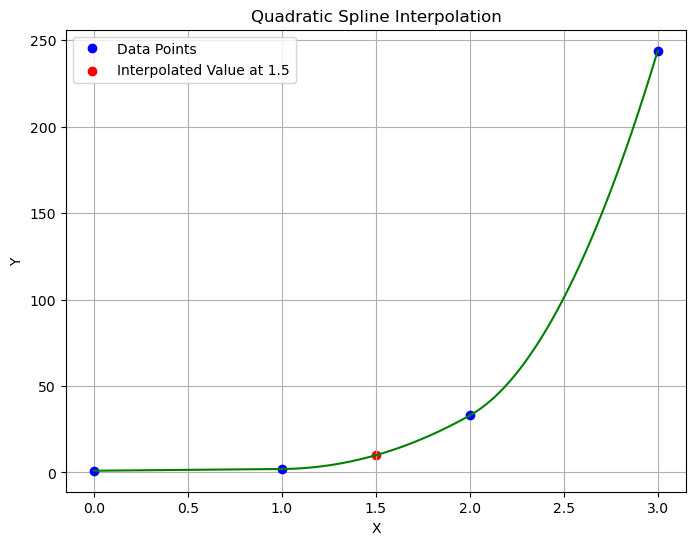

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def quadratic_spline(x, y, xp):
    n = len(x) - 1
    # Matrix A for the linear system of equations (3n unknowns)
    A = np.zeros((3 * n, 3 * n))
    b = np.zeros(3 * n)

    equations = []

    # Setting up equations for spline segments
    row = 0
    for i in range(n):
        # Spline passes through the left endpoint of the interval
        A[row, 3 * i] = x[i]**2
        A[row, 3 * i + 1] = x[i]
        A[row, 3 * i + 2] = 1
        b[row] = y[i]
        row += 1

        # Spline passes through the right endpoint of the interval
        A[row, 3 * i] = x[i + 1]**2
        A[row, 3 * i + 1] = x[i + 1]
        A[row, 3 * i + 2] = 1
        b[row] = y[i + 1]
        row += 1

    # Continuity condition (first derivatives match at internal points)
    for i in range(n - 1):
        # 2*a_i*x + b_i = 2*a_{i+1}*x + b_{i+1}
        A[row, 3 * i] = 2 * x[i + 1]
        A[row, 3 * i + 1] = 1
        A[row, 3 * i + 3] = -2 * x[i + 1]
        A[row, 3 * i + 4] = -1
        row += 1

    # Natural spline condition (second derivative at the first point is zero)
    # This implies 2*a_0 = 0, so a_0 = 0
    A[row, 0] = 2
    row += 1
    # A[row, 3*(n-1) + 2] = 2  # Corrected index to avoid out-of-bounds error
    # row += 1

    # Solve the system of linear equations for the coefficients
    coeffs = np.linalg.solve(A, b)

    # Constructing spline equations for printing
    for i in range(n):
        # Extract a, b, c for each segment S_i(x) = ax^2 + bx + c
        a, b_val, c = coeffs[3 * i : 3 * i + 3]
        eq = f"S_{i}(x) = {a:.4f}x^2 + {b_val:.4f}x + {c:.4f}, for {x[i]} <= x <= {x[i+1]}"
        equations.append(eq)
        print(eq)

    # Finding interpolated value for the specific point xp
    y_interp = None
    for i in range(n):
        if x[i] <= xp <= x[i + 1]:
            # Apply the specific segment's quadratic formula
            y_interp = coeffs[3 * i] * xp**2 + coeffs[3 * i + 1] * xp + coeffs[3 * i + 2]
            break

    return equations, y_interp, coeffs

# Example Data Points
# x_points = np.array([1, 2, 3, 4, 5])
# y_points = np.array([2, 3, 5, 7, 11])
x_points = np.array([0, 1, 2, 3])
y_points = np.array([1, 2, 33, 244])

# Interpolation Point
x_interp = 1.5
splines, y_interp, coeffs = quadratic_spline(x_points, y_points, x_interp)
print(f"Interpolated value at x = {x_interp}: {y_interp:.4f}")

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(x_points, y_points, 'bo', label='Data Points')
plt.scatter(x_interp, y_interp, color='red', label=f'Interpolated Value at {x_interp}')

# Plot quadratic spline segments
for i in range(len(x_points) - 1):
    # Generate points within each interval to draw the curve
    x_vals = np.linspace(x_points[i], x_points[i + 1], 100)
    y_vals = (coeffs[3 * i] * x_vals**2 + coeffs[3 * i + 1] * x_vals + coeffs[3 * i + 2])
    plt.plot(x_vals, y_vals, 'g-')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Quadratic Spline Interpolation')
plt.legend()
plt.grid(True)
plt.show()

S_0(x) = 0.0000x^2 + 1.0000x + 1.0000, for 1 <= x <= 2
S_1(x) = 1.0000x^2 + -3.0000x + 5.0000, for 2 <= x <= 3
S_2(x) = -1.0000x^2 + 9.0000x + -13.0000, for 3 <= x <= 4
S_3(x) = 3.0000x^2 + -23.0000x + 51.0000, for 4 <= x <= 5
Interpolated value at x = 2.5: 3.7500


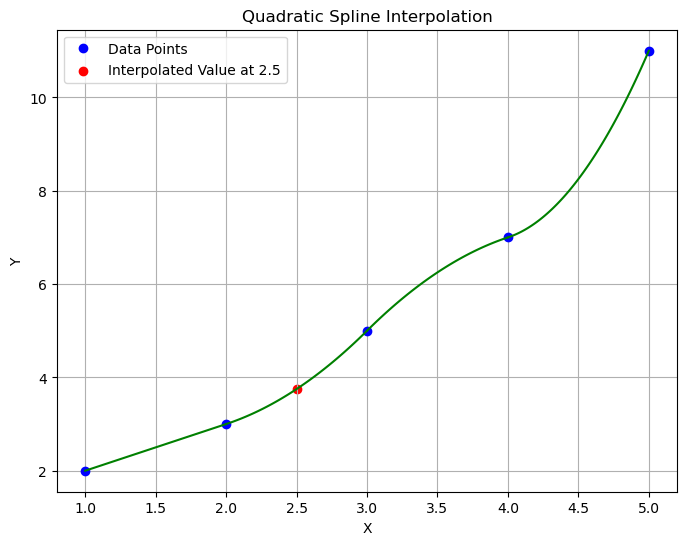

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def quadratic_spline(x, y, xp):
    n = len(x) - 1
    # Matrix A for the linear system of equations (3n unknowns)
    A = np.zeros((3 * n, 3 * n))
    b = np.zeros(3 * n)

    equations = []

    # Setting up equations for spline segments
    row = 0
    for i in range(n):
        # Spline passes through the left endpoint of the interval
        A[row, 3 * i] = x[i]**2
        A[row, 3 * i + 1] = x[i]
        A[row, 3 * i + 2] = 1
        b[row] = y[i]
        row += 1

        # Spline passes through the right endpoint of the interval
        A[row, 3 * i] = x[i + 1]**2
        A[row, 3 * i + 1] = x[i + 1]
        A[row, 3 * i + 2] = 1
        b[row] = y[i + 1]
        row += 1

    # Continuity condition (first derivatives match at internal points)
    for i in range(n - 1):
        # 2*a_i*x + b_i = 2*a_{i+1}*x + b_{i+1}
        A[row, 3 * i] = 2 * x[i + 1]
        A[row, 3 * i + 1] = 1
        A[row, 3 * i + 3] = -2 * x[i + 1]
        A[row, 3 * i + 4] = -1
        row += 1

    # Natural spline condition (second derivative at the first point is zero)
    # This implies 2*a_0 = 0, so a_0 = 0
    A[row, 0] = 2
    row += 1
    # A[row, 3*(n-1) + 2] = 2  # Corrected index to avoid out-of-bounds error
    # row += 1

    # Solve the system of linear equations for the coefficients
    coeffs = np.linalg.solve(A, b)

    # Constructing spline equations for printing
    for i in range(n):
        # Extract a, b, c for each segment S_i(x) = ax^2 + bx + c
        a, b_val, c = coeffs[3 * i : 3 * i + 3]
        eq = f"S_{i}(x) = {a:.4f}x^2 + {b_val:.4f}x + {c:.4f}, for {x[i]} <= x <= {x[i+1]}"
        equations.append(eq)
        print(eq)

    # Finding interpolated value for the specific point xp
    y_interp = None
    for i in range(n):
        if x[i] <= xp <= x[i + 1]:
            # Apply the specific segment's quadratic formula
            y_interp = coeffs[3 * i] * xp**2 + coeffs[3 * i + 1] * xp + coeffs[3 * i + 2]
            break

    return equations, y_interp, coeffs

# Example Data Points
x_points = np.array([1, 2, 3, 4, 5])
y_points = np.array([2, 3, 5, 7, 11])
#x_points = np.array([0, 1, 2, 3])
#y_points = np.array([1, 2, 33, 244])

# Interpolation Point
x_interp = 2.5
splines, y_interp, coeffs = quadratic_spline(x_points, y_points, x_interp)
print(f"Interpolated value at x = {x_interp}: {y_interp:.4f}")

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(x_points, y_points, 'bo', label='Data Points')
plt.scatter(x_interp, y_interp, color='red', label=f'Interpolated Value at {x_interp}')

# Plot quadratic spline segments
for i in range(len(x_points) - 1):
    # Generate points within each interval to draw the curve
    x_vals = np.linspace(x_points[i], x_points[i + 1], 100)
    y_vals = (coeffs[3 * i] * x_vals**2 + coeffs[3 * i + 1] * x_vals + coeffs[3 * i + 2])
    plt.plot(x_vals, y_vals, 'g-')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Quadratic Spline Interpolation')
plt.legend()
plt.grid(True)
plt.show()

S_0(x) = 0.0000x^2 + 1.0000x + 1.0000, for 1 <= x <= 2
S_1(x) = 1.0000x^2 + -3.0000x + 5.0000, for 2 <= x <= 3
S_2(x) = -1.0000x^2 + 9.0000x + -13.0000, for 3 <= x <= 4
S_3(x) = 3.0000x^2 + -23.0000x + 51.0000, for 4 <= x <= 5
Interpolated value at x = 1.5: 2.5000


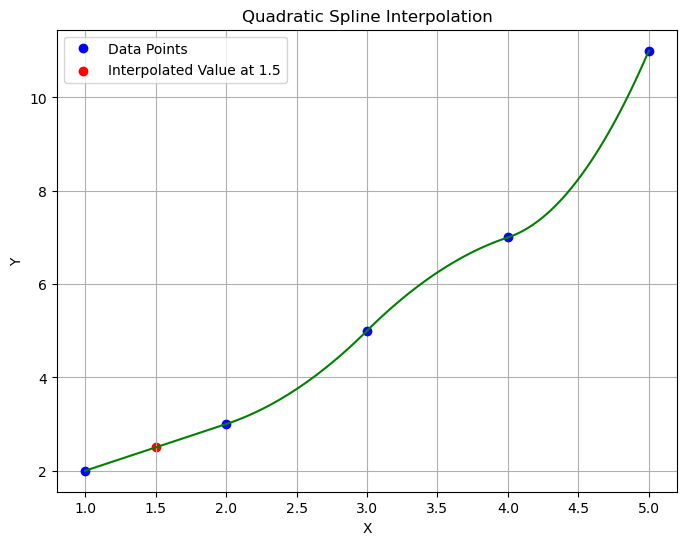

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def quadratic_spline(x, y, xp):
    n = len(x) - 1
    # Matrix A for the linear system of equations (3n unknowns)
    A = np.zeros((3 * n, 3 * n))
    b = np.zeros(3 * n)

    equations = []

    # Setting up equations for spline segments
    row = 0
    for i in range(n):
        # Spline passes through the left endpoint of the interval
        A[row, 3 * i] = x[i]**2
        A[row, 3 * i + 1] = x[i]
        A[row, 3 * i + 2] = 1
        b[row] = y[i]
        row += 1

        # Spline passes through the right endpoint of the interval
        A[row, 3 * i] = x[i + 1]**2
        A[row, 3 * i + 1] = x[i + 1]
        A[row, 3 * i + 2] = 1
        b[row] = y[i + 1]
        row += 1

    # Continuity condition (first derivatives match at internal points)
    for i in range(n - 1):
        # 2*a_i*x + b_i = 2*a_{i+1}*x + b_{i+1}
        A[row, 3 * i] = 2 * x[i + 1]
        A[row, 3 * i + 1] = 1
        A[row, 3 * i + 3] = -2 * x[i + 1]
        A[row, 3 * i + 4] = -1
        row += 1

    # Natural spline condition (second derivative at the first point is zero)
    # This implies 2*a_0 = 0, so a_0 = 0
    A[row, 0] = 2
    row += 1
    # A[row, 3*(n-1) + 2] = 2  # Corrected index to avoid out-of-bounds error
    # row += 1

    # Solve the system of linear equations for the coefficients
    coeffs = np.linalg.solve(A, b)

    # Constructing spline equations for printing
    for i in range(n):
        # Extract a, b, c for each segment S_i(x) = ax^2 + bx + c
        a, b_val, c = coeffs[3 * i : 3 * i + 3]
        eq = f"S_{i}(x) = {a:.4f}x^2 + {b_val:.4f}x + {c:.4f}, for {x[i]} <= x <= {x[i+1]}"
        equations.append(eq)
        print(eq)

    # Finding interpolated value for the specific point xp
    y_interp = None
    for i in range(n):
        if x[i] <= xp <= x[i + 1]:
            # Apply the specific segment's quadratic formula
            y_interp = coeffs[3 * i] * xp**2 + coeffs[3 * i + 1] * xp + coeffs[3 * i + 2]
            break

    return equations, y_interp, coeffs

# Example Data Points
x_points = np.array([1, 2, 3, 4, 5])
y_points = np.array([2, 3, 5, 7, 11])
#x_points = np.array([0, 1, 2, 3])
#y_points = np.array([1, 2, 33, 244])

# Interpolation Point
x_interp = 1.5
splines, y_interp, coeffs = quadratic_spline(x_points, y_points, x_interp)
print(f"Interpolated value at x = {x_interp}: {y_interp:.4f}")

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(x_points, y_points, 'bo', label='Data Points')
plt.scatter(x_interp, y_interp, color='red', label=f'Interpolated Value at {x_interp}')

# Plot quadratic spline segments
for i in range(len(x_points) - 1):
    # Generate points within each interval to draw the curve
    x_vals = np.linspace(x_points[i], x_points[i + 1], 100)
    y_vals = (coeffs[3 * i] * x_vals**2 + coeffs[3 * i + 1] * x_vals + coeffs[3 * i + 2])
    plt.plot(x_vals, y_vals, 'g-')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Quadratic Spline Interpolation')
plt.legend()
plt.grid(True)
plt.show()